# The Lotka-Volterra model - SLXVIC001
This model is a python translation of the LV_pz model proposed in Glover et al. (2011), Sec. 9.3

You will need to make sure the required modules below are installed in your python environment

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

This is the function containing the right hand side of the ODE system

In [2]:
def LV_pz(x,t,p):
    X1,X2 = x
    p1,p2,p3,p4 = p
    dX1dt = X1 * (p1 - p2*X2)
    dX2dt = X2 * (p3*p2*X1 - p4)
    return np.array([dX1dt,dX2dt])

## Parameters and initial conditions

In [3]:
# The parameters
p = np.array([0.1,0.4,0.2,0.05])
X1_0 = 0.8
X2_0 = 0.171
x0 = np.array([X1_0,X2_0])

## Time axis

In [4]:
# time units are days
Tstart = 0.
Tend = 400.
step = 0.1
t = np.arange(Tstart,Tend,step)

## Integration using the scipy ODE solver

In [5]:
# note that the extra argument containing the parameter "args" must be a tuple
y = odeint(LV_pz, x0, t, args=(p,))

## Plot Fig. 9.3a

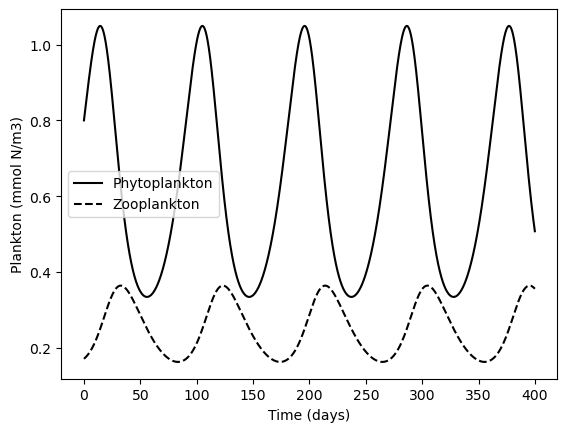

In [6]:
plt.plot(t,y[:,0],'k-',label='Phytoplankton')
plt.plot(t,y[:,1],'k--',label='Zooplankton')
plt.xlabel('Time (days)')
plt.ylabel('Plankton (mmol N/m3)')
plt.legend()
plt.show()

# Exercise 3
### 1. Write the code to plot Fig. 9.3b, the trajectory in the phase space

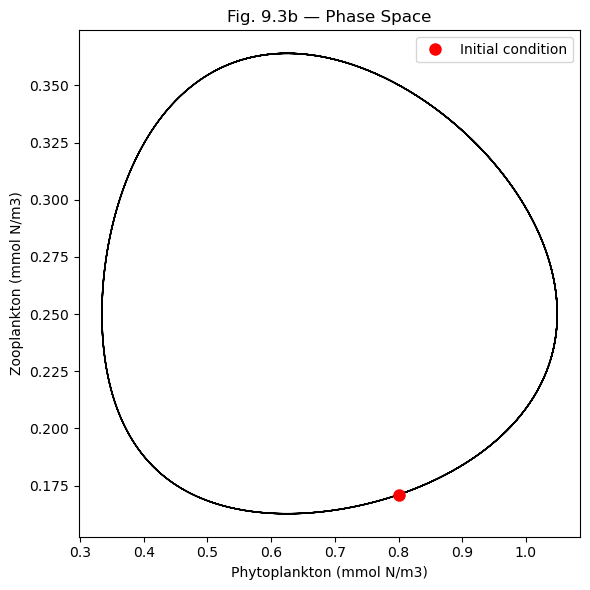

In [9]:
plt.figure(figsize=(6, 6))
plt.plot(y[:,0], y[:,1], 'k-', linewidth=1)
plt.plot(X1_0, X2_0, 'ro', markersize=8, label='Initial condition')
plt.xlabel('Phytoplankton (mmol N/m3)')
plt.ylabel('Zooplankton (mmol N/m3)')
plt.title('Fig. 9.3b — Phase Space')
plt.legend()
plt.tight_layout()
plt.show()

### 2. Set the parameter p3=1 and compare how different the trajectory is in the phase space.
Higher p3 = higher assimilation efficiency → zooplankton grow more per unit of phytoplankton eaten → larger orbit, bigger Z oscillations

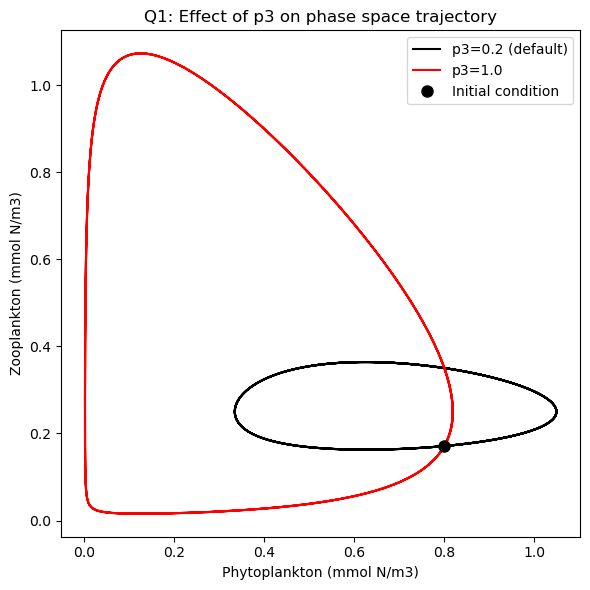

In [17]:
p_mod = np.array([0.1, 0.4, 1.0, 0.05])   # only p3 changed
y_mod = odeint(LV_pz, x0, t, args=(p_mod,))

plt.figure(figsize=(6, 6))
plt.plot(y[:,0],     y[:,1],     'k-', linewidth=1.5, label='p3=0.2 (default)')
plt.plot(y_mod[:,0], y_mod[:,1], 'r-', linewidth=1.5, label='p3=1.0')
plt.plot(X1_0, X2_0, 'ko', markersize=8, label='Initial condition')
plt.xlabel('Phytoplankton (mmol N/m3)')
plt.ylabel('Zooplankton (mmol N/m3)')
plt.title('Q1: Effect of p3 on phase space trajectory')
plt.legend()
plt.tight_layout()
plt.show()

3. Write the code to compute the solution of the L-V model using the initial conditions given in the caption of Fig. 9.4

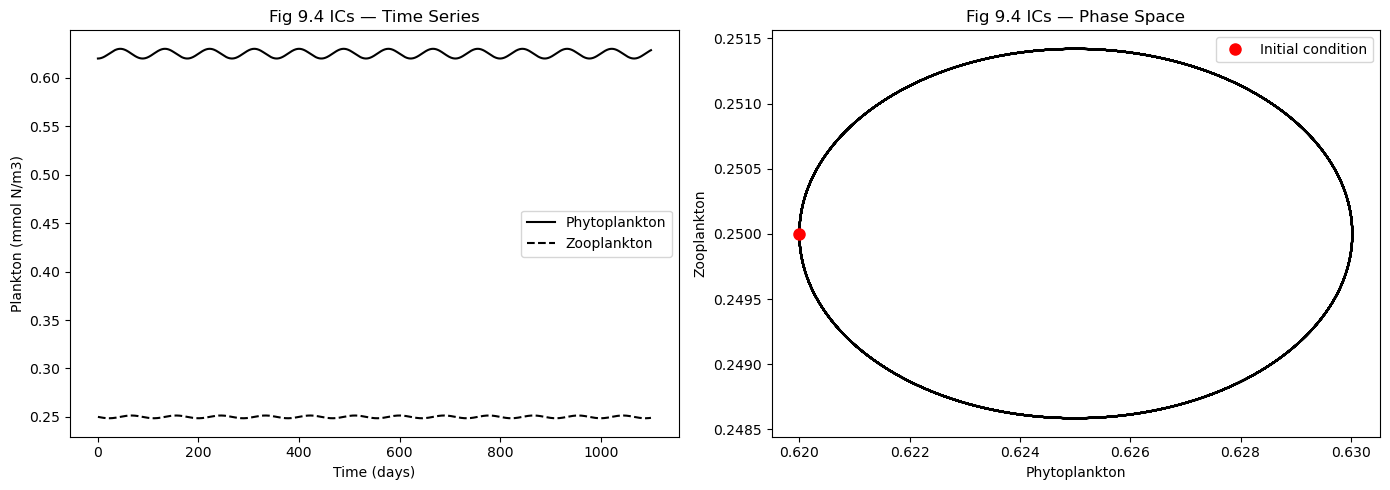

In [15]:
X1_0_g = 0.62
X2_0_g = 0.25
x0_g   = np.array([X1_0_g, X2_0_g])

t_g = np.arange(0., 1100., step)

y_g = odeint(LV_pz, x0_g, t_g, args=(p,))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t_g, y_g[:,0], 'k-',  label='Phytoplankton')
axes[0].plot(t_g, y_g[:,1], 'k--', label='Zooplankton')
axes[0].set_xlabel('Time (days)'); axes[0].set_ylabel('Plankton (mmol N/m3)')
axes[0].set_title('Fig 9.4 ICs — Time Series'); axes[0].legend()

axes[1].plot(y_g[:,0], y_g[:,1], 'k-', linewidth=1.5)
axes[1].plot(X1_0_g, X2_0_g, 'ro', markersize=8, label='Initial condition')
axes[1].set_xlabel('Phytoplankton'); axes[1].set_ylabel('Zooplankton')
axes[1].set_title('Fig 9.4 ICs — Phase Space'); axes[1].legend()

plt.tight_layout()
plt.show()

### 4. Do you get the same results? Why not? See the errata in the document Glover_etal_2011_ERRATA.pdf to understand more {no need to fully understand the stability analysis ;)}
No, the results differed from the results in Glover et al. In the textbook, there is a typo in the printed parameters. If thesen parameters are changed, they change the entire trajectory of the plot, explaining why using the given values would not reproduce the printed plot.